# RayShootingOptimizer — Demo

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import time

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from optimizer import RayShootingOptimizer

torch.manual_seed(42)
np.random.seed(42)
print('Setup complete.')

Setup complete.


## Test surfaces

Each surface has two versions:
- `f(x)` — scalar, takes `(d,)`, returns scalar tensor. Used for gradient ascent.
- `f_batch(xs)` — batched, takes `(N, d)`, returns `(N,)` tensor. Used for vectorized ray evaluation.

All surfaces are negated so the global optimum is a **maximum** at the known location.

| Surface | Character | Global max | Why it is hard for local methods |
|---|---|---|---|
| Ackley | Shallow local optima surrounding a deep central peak | 0.0 at `(0,0)` | Many local peaks of similar height |
| Rastrigin | Dense regular grid of local optima | 0.0 at `(0,0)` | ~10 local peaks per unit — Adam almost always gets trapped |
| Levy | Smooth with one narrow global basin and many flat shoulders | 0.0 at `(1,1)` | Flat regions give near-zero gradient; easy to stall before the global |
| Griewank | Like Rastrigin but with a smooth bowl modulating the oscillations | 0.0 at `(0,0)` | Coupling between dimensions makes the grid irregular and hard to escape |
| Bukin N.6 | Narrow curved ridge with steep walls on both sides | 0.0 at `(-10, 1)` | Ridge is extremely thin — gradient ascent slides off unless exactly on it |

In [2]:
# --- Ackley ---
def neg_ackley(x: torch.Tensor) -> torch.Tensor:
    """Scalar. x: (d,) → scalar tensor."""
    a, b, c = 20.0, 0.2, 2 * np.pi
    d = x.shape[0]
    val = (-a * torch.exp(-b * torch.sqrt(torch.sum(x**2) / d))
           - torch.exp(torch.sum(torch.cos(c * x)) / d) + a + np.e)
    return -val

def neg_ackley_batch(xs: torch.Tensor) -> torch.Tensor:
    """Batched. xs: (N, d) → (N,) tensor."""
    a, b, c = 20.0, 0.2, 2 * np.pi
    d = xs.shape[1]
    val = (-a * torch.exp(-b * torch.sqrt(torch.sum(xs**2, dim=1) / d))
           - torch.exp(torch.sum(torch.cos(c * xs), dim=1) / d) + a + np.e)
    return -val


# --- Rastrigin ---
def neg_rastrigin(x: torch.Tensor) -> torch.Tensor:
    """Scalar. x: (d,) → scalar tensor."""
    d = x.shape[0]
    return -(10 * d + torch.sum(x**2 - 10 * torch.cos(2 * np.pi * x)))

def neg_rastrigin_batch(xs: torch.Tensor) -> torch.Tensor:
    """Batched. xs: (N, d) → (N,) tensor."""
    d = xs.shape[1]
    return -(10 * d + torch.sum(xs**2 - 10 * torch.cos(2 * np.pi * xs), dim=1))


# --- Levy ---
# Global max at (1, 1) = 0. Smooth with flat shoulders that stall local methods.
def _levy_w(x: torch.Tensor) -> torch.Tensor:
    return 1 + (x - 1) / 4

def neg_levy(x: torch.Tensor) -> torch.Tensor:
    """Scalar. x: (d,) → scalar tensor. Domain: [-10, 10]^2."""
    w = _levy_w(x)
    d = x.shape[0]
    val = (torch.sin(np.pi * w[0]) ** 2
           + torch.sum((w[:-1] - 1)**2 * (1 + 10 * torch.sin(np.pi * w[:-1] + 1)**2))
           + (w[-1] - 1)**2 * (1 + torch.sin(2 * np.pi * w[-1])**2))
    return -val

def neg_levy_batch(xs: torch.Tensor) -> torch.Tensor:
    """Batched. xs: (N, d) → (N,) tensor."""
    w = 1 + (xs - 1) / 4
    val = (torch.sin(np.pi * w[:, 0]) ** 2
           + torch.sum((w[:, :-1] - 1)**2 * (1 + 10 * torch.sin(np.pi * w[:, :-1] + 1)**2), dim=1)
           + (w[:, -1] - 1)**2 * (1 + torch.sin(2 * np.pi * w[:, -1])**2))
    return -val


# --- Griewank ---
# Global max at (0, 0) = 0. Smooth bowl + high-frequency cosine coupling.
def neg_griewank(x: torch.Tensor) -> torch.Tensor:
    """Scalar. x: (d,) → scalar tensor. Domain: [-600, 600]^2."""
    d = x.shape[0]
    i = torch.arange(1, d + 1, dtype=torch.float32)
    val = torch.sum(x**2) / 4000 - torch.prod(torch.cos(x / torch.sqrt(i))) + 1
    return -val

def neg_griewank_batch(xs: torch.Tensor) -> torch.Tensor:
    """Batched. xs: (N, d) → (N,) tensor."""
    d = xs.shape[1]
    i = torch.arange(1, d + 1, dtype=torch.float32)
    val = (torch.sum(xs**2, dim=1) / 4000
           - torch.prod(torch.cos(xs / torch.sqrt(i)), dim=1) + 1)
    return -val


# --- Bukin N.6 ---
# Global max at (-10, 1) = 0. Extremely narrow curved ridge; steep walls.
def neg_bukin6(x: torch.Tensor) -> torch.Tensor:
    """Scalar. x: (2,) → scalar tensor. Domain: x1 in [-15,-5], x2 in [-3,3]."""
    x1, x2 = x[0], x[1]
    val = 100 * torch.sqrt(torch.abs(x2 - 0.01 * x1**2)) + 0.01 * torch.abs(x1 + 10)
    return -val

def neg_bukin6_batch(xs: torch.Tensor) -> torch.Tensor:
    """Batched. xs: (N, 2) → (N,) tensor."""
    x1, x2 = xs[:, 0], xs[:, 1]
    val = 100 * torch.sqrt(torch.abs(x2 - 0.01 * x1**2)) + 0.01 * torch.abs(x1 + 10)
    return -val


SURFACES = {
    'Ackley': {
        'f':         neg_ackley,
        'f_batch':   neg_ackley_batch,
        'bounds':    5.0,
        'known_max': 0.0,
        'known_loc': [0.0, 0.0],
    },
    'Rastrigin': {
        'f':         neg_rastrigin,
        'f_batch':   neg_rastrigin_batch,
        'bounds':    5.12,
        'known_max': 0.0,
        'known_loc': [0.0, 0.0],
    },
    'Levy': {
        'f':         neg_levy,
        'f_batch':   neg_levy_batch,
        'bounds':    10.0,
        'known_max': 0.0,
        'known_loc': [1.0, 1.0],
    },
    'Griewank': {
        'f':         neg_griewank,
        'f_batch':   neg_griewank_batch,
        'bounds':    50.0,   # zoomed in — full domain [-600,600] is too sparse to visualize
        'known_max': 0.0,
        'known_loc': [0.0, 0.0],
    },
    'Bukin6': {
        'f':         neg_bukin6,
        'f_batch':   neg_bukin6_batch,
        'bounds':    10.0,   # centred display; true domain is asymmetric
        'known_max': 0.0,
        'known_loc': [-10.0, 1.0],
    },
}

print(f'Surfaces defined: {list(SURFACES.keys())}')

Surfaces defined: ['Ackley', 'Rastrigin', 'Levy', 'Griewank', 'Bukin6']


## Baseline helpers: Adam and SGD as maximizers

Both use `(-f(x)).backward()` to turn PyTorch's minimizers into maximizers.

In [3]:
def run_adam(f, start: torch.Tensor, lr: float = 0.05, steps: int = 400):
    """Maximize f from start using PyTorch Adam. Returns (best_point, best_value)."""
    x = start.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([x], lr=lr)
    best_val, best_x = float('-inf'), x.detach().clone()
    for _ in range(steps):
        opt.zero_grad()
        (-f(x)).backward()
        opt.step()
        val = f(x.detach()).item()
        if val > best_val:
            best_val, best_x = val, x.detach().clone()
    return best_x, best_val


def run_sgd(f, start: torch.Tensor, lr: float = 0.01, momentum: float = 0.9, steps: int = 400):
    """Maximize f from start using PyTorch SGD with momentum. Returns (best_point, best_value)."""
    x = start.clone().detach().requires_grad_(True)
    opt = torch.optim.SGD([x], lr=lr, momentum=momentum)
    best_val, best_x = float('-inf'), x.detach().clone()
    for _ in range(steps):
        opt.zero_grad()
        (-f(x)).backward()
        opt.step()
        val = f(x.detach()).item()
        if val > best_val:
            best_val, best_x = val, x.detach().clone()
    return best_x, best_val


print('Baseline helpers defined.')

Baseline helpers defined.


## Visualization helper

In [4]:
def build_contour(f_batch, bounds, res=250):
    """Pre-compute contour grid using batched evaluation."""
    xs = np.linspace(-bounds, bounds, res)
    ys = np.linspace(-bounds, bounds, res)
    X, Y = np.meshgrid(xs, ys)
    pts = torch.tensor(
        np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32
    )  # (res*res, 2)
    with torch.no_grad():
        Z = f_batch(pts).numpy().reshape(res, res)
    return X, Y, Z


def plot_result(ax, X, Y, Z, bounds, results, known_loc, known_max, title):
    """
    results: list of (label, point_tensor, value, color, marker)
    """
    ax.contourf(X, Y, Z, levels=40, cmap='viridis', alpha=0.85)
    ax.contour(X, Y, Z,  levels=15, colors='white', alpha=0.15, linewidths=0.4)
    ax.scatter(*known_loc, color='cyan', s=110, zorder=7, marker='^',
               label=f'Global ({known_max:.4f})', edgecolors='white', linewidths=0.8)
    for label, pt, val, color, marker in results:
        ax.scatter(*pt.numpy(), color=color, s=150, zorder=8, marker=marker,
                   label=f'{label} ({val:.4f})', edgecolors='white', linewidths=0.5)
    ax.set_xlim(-bounds, bounds)
    ax.set_ylim(-bounds, bounds)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('x\u2081')
    ax.set_ylabel('x\u2082')
    ax.legend(fontsize=8, loc='upper right', framealpha=0.75)


print('Visualization helpers defined.')

Visualization helpers defined.


## 1. Single-run comparison on all surfaces

In [ ]:
STARTS = {
    'Ackley':      torch.tensor([3.5,    -3.0],   dtype=torch.float32),
    'Rastrigin':   torch.tensor([4.5,     2.5],   dtype=torch.float32),
    'Levy':        torch.tensor([-8.0,    7.0],   dtype=torch.float32),
    'Griewank':    torch.tensor([40.0,  -35.0],   dtype=torch.float32),
    'Bukin6':      torch.tensor([-6.0,   -2.0],   dtype=torch.float32),
}

# An interesting thing, for Rastrigin, if we reduce num_rays from 5 to 2 it loses a ton of accuracy but for any above 4 it remains really accurate.

RSO_CONFIGS = {
    'Ackley':      dict(lr=0.05, ascent_steps=50, num_rays=5, ray_step_size=0.1,   max_iterations=8,  epsilon=1e-2, max_param_step_norm=0.05,  top_k_landings=1),
    'Rastrigin':   dict(lr=0.05, ascent_steps=3, num_rays=5, ray_step_size=0.08,  max_iterations=10, epsilon=1e-2, max_param_step_norm=0.05,  top_k_landings=1),
    'Levy':        dict(lr=0.05, ascent_steps=400, num_rays=24, ray_step_size=0.2,   max_iterations=8,  epsilon=1e-5, max_param_step_norm=0.05,  top_k_landings=5),
    'Griewank':    dict(lr=0.2,  ascent_steps=400, num_rays=32, ray_step_size=1.0,   max_iterations=10, epsilon=1e-5, max_param_step_norm=0.2,   top_k_landings=5),
    'Bukin6':      dict(lr=0.01, ascent_steps=500, num_rays=32, ray_step_size=0.1,   max_iterations=10, epsilon=1e-5, max_param_step_norm=0.01,  top_k_landings=5),
}

single_run_results = {}

for name, surface in SURFACES.items():
    start = STARTS[name]
    f, f_batch = surface['f'], surface['f_batch']

    rso_pt,  rso_val  = RayShootingOptimizer(**RSO_CONFIGS[name]).optimize(f, start, f_batch=f_batch)
    adam_pt, adam_val = run_adam(f, start, lr=0.05, steps=400)
    sgd_pt,  sgd_val  = run_sgd( f, start, lr=0.01, steps=400)

    single_run_results[name] = {
        'RSO':  (rso_pt,  rso_val),
        'Adam': (adam_pt, adam_val),
        'SGD':  (sgd_pt,  sgd_val),
    }

    known = surface['known_max']
    print(f"\n{name}  (start: {start.numpy()})")
    print(f"  RSO:    {rso_val:>12.5f}   gap = {abs(rso_val  - known):.5f}")
    print(f"  Adam:   {adam_val:>12.5f}   gap = {abs(adam_val - known):.5f}")
    print(f"  SGD:    {sgd_val:>12.5f}   gap = {abs(sgd_val  - known):.5f}")
    print(f"  Global: {known:>12.5f}")


Ackley  (start: [ 3.5 -3. ])
  RSO:        -0.16060   gap = 0.16060
  Adam:       -9.00109   gap = 9.00109
  SGD:        -9.00109   gap = 9.00109
  Global:      0.00000

Rastrigin  (start: [4.5 2.5])
  RSO:        -5.16538   gap = 5.16538
  Adam:      -19.89907   gap = 19.89907
  SGD:       -19.43833   gap = 19.43833
  Global:      0.00000

Levy  (start: [-8.  7.])
  RSO:        -0.00082   gap = 0.00082
  Adam:       -8.28012   gap = 8.28012
  SGD:        -8.28012   gap = 8.28012
  Global:      0.00000

Griewank  (start: [ 40. -35.])
  RSO:        -0.00774   gap = 0.00774
  Adam:       -0.67064   gap = 0.67064
  SGD:        -0.67064   gap = 0.67064
  Global:      0.00000

Bukin6  (start: [-6. -2.])
  RSO:        -6.86200   gap = 6.86200
  Adam:       -0.96847   gap = 0.96847
  SGD:        -7.86932   gap = 7.86932
  Global:      0.00000


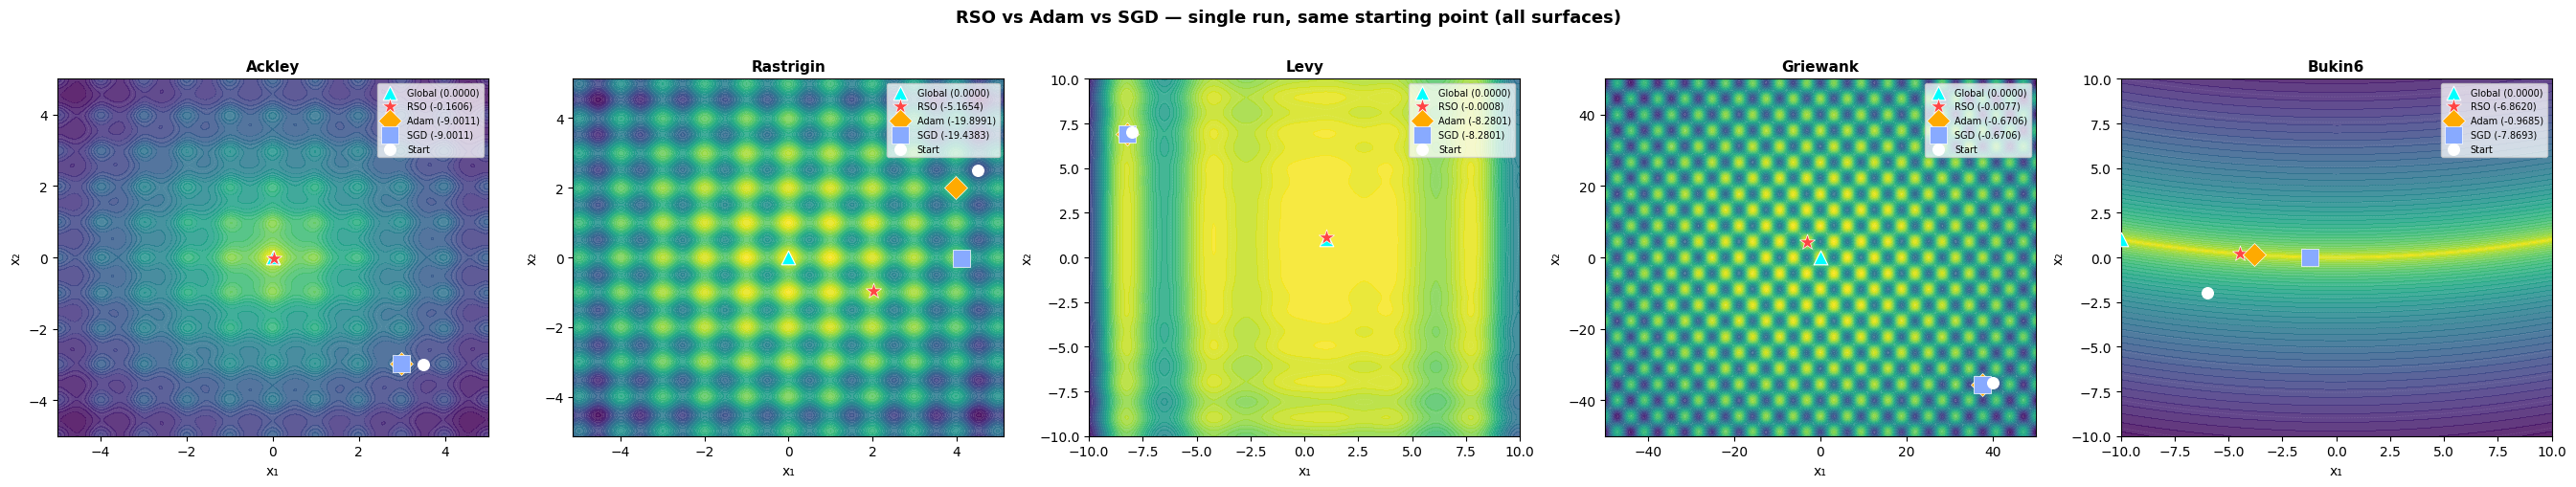

In [6]:
# Plot in a single row of 5
names = list(SURFACES.keys())
fig, axes = plt.subplots(1, 5, figsize=(27, 5))

for ax, name in zip(axes, names):
    surface = SURFACES[name]
    X, Y, Z = build_contour(surface['f_batch'], surface['bounds'])
    res = single_run_results[name]
    plot_result(
        ax, X, Y, Z, surface['bounds'],
        results=[
            ('RSO',  res['RSO'][0],  res['RSO'][1],  '#ff4444', '*'),
            ('Adam', res['Adam'][0], res['Adam'][1], '#ffaa00', 'D'),
            ('SGD',  res['SGD'][0],  res['SGD'][1],  '#88aaff', 's'),
        ],
        known_loc=surface['known_loc'],
        known_max=surface['known_max'],
        title=name,
    )
    ax.scatter(*STARTS[name].numpy(), color='white', s=70, zorder=9, marker='o', label='Start')
    ax.legend(fontsize=7, loc='upper right', framealpha=0.75)

plt.suptitle('RSO vs Adam vs SGD — single run, same starting point (all surfaces)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('single_run_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Monte Carlo benchmark: 30 random starts on all surfaces

A single start can be lucky or unlucky. We run 30 random starts per surface and measure each method's gap to the global optimum. Running across all five surfaces lets us see which failure modes are specific to a surface type (dense local optima vs flat shoulders vs narrow ridges) and which are general.

In [7]:
n_trials = 30
mc_results = {}  # mc_results[surface_name][method] = {'gaps': [...], 'times': [...]}

for name, surface in SURFACES.items():
    f       = surface['f']
    f_batch = surface['f_batch']
    known   = surface['known_max']
    bounds  = surface['bounds']

    rso = RayShootingOptimizer(**RSO_CONFIGS[name])
    res = {m: {'gaps': [], 'times': []} for m in ['RSO', 'Adam', 'SGD']}

    torch.manual_seed(7)
    for _ in range(n_trials):
        start = torch.empty(2).uniform_(-bounds * 0.85, bounds * 0.85)

        t0 = time.time(); _, v = rso.optimize(f, start, f_batch=f_batch);        res['RSO']['times'].append(time.time()-t0); res['RSO']['gaps'].append(abs(v - known))
        t0 = time.time(); _, v = run_adam(f, start, lr=0.05, steps=400);         res['Adam']['times'].append(time.time()-t0); res['Adam']['gaps'].append(abs(v - known))
        t0 = time.time(); _, v = run_sgd( f, start, lr=0.01, steps=400);         res['SGD']['times'].append(time.time()-t0); res['SGD']['gaps'].append(abs(v - known))

    mc_results[name] = res

    print(f"\n{name} — {n_trials} random starts")
    print(f"  {'Method':<6} {'Mean gap':>10} {'Std':>8} {'Found (gap<0.05)':>18} {'Mean time':>10}")
    print(f"  {'-'*56}")
    for m in ['RSO', 'Adam', 'SGD']:
        g = res[m]['gaps']
        found = sum(v < 0.05 for v in g)
        print(f"  {m:<6} {np.mean(g):>10.4f} {np.std(g):>8.4f} {found:>10}/{n_trials}        {np.mean(res[m]['times']):>6.3f}s")


Ackley — 30 random starts
  Method   Mean gap      Std   Found (gap<0.05)  Mean time
  --------------------------------------------------------
  RSO        0.2717   0.6289          5/30         0.120s
  Adam       6.4687   2.3485          1/30         0.112s
  SGD        5.5230   3.1018          3/30         0.101s

Rastrigin — 30 random starts
  Method   Mean gap      Std   Found (gap<0.05)  Mean time
  --------------------------------------------------------
  RSO        1.6597   1.2048          1/30         0.045s
  Adam      10.6460   6.7488          0/30         0.082s
  SGD        9.5746   6.2908          0/30         0.070s

Levy — 30 random starts
  Method   Mean gap      Std   Found (gap<0.05)  Mean time
  --------------------------------------------------------
  RSO        0.0096   0.0157         30/30         0.247s
  Adam       2.9292   2.1482          4/30         0.170s
  SGD        2.6869   2.2405          7/30         0.159s

Griewank — 30 random starts
  Method   Me

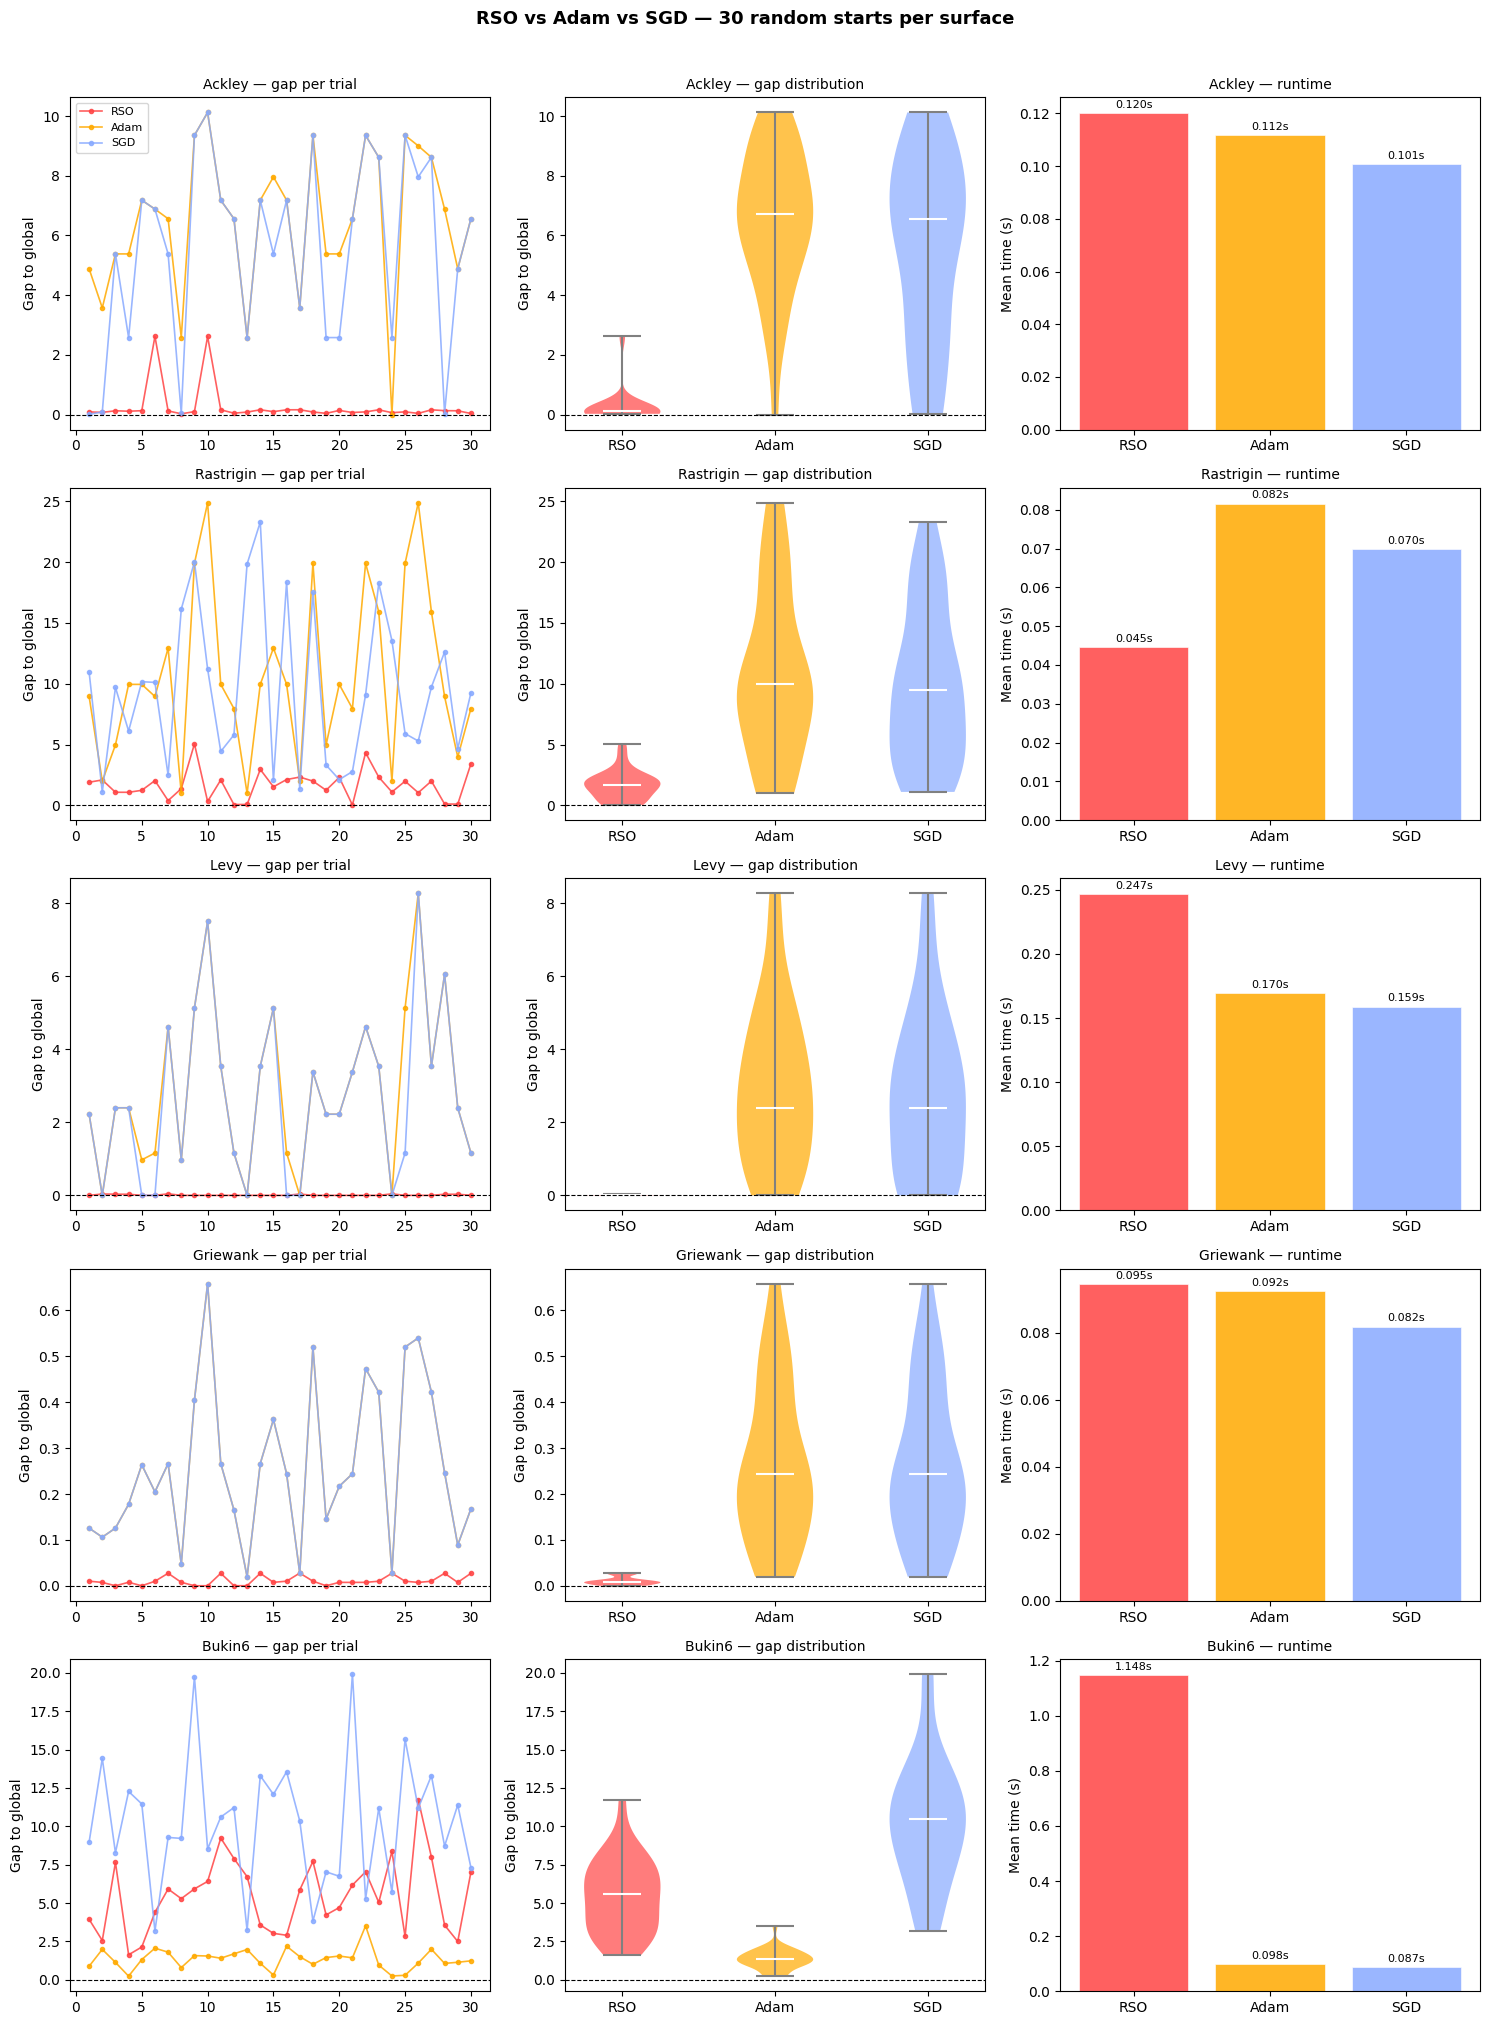

In [8]:
colors = {'RSO': '#ff4444', 'Adam': '#ffaa00', 'SGD': '#88aaff'}
surface_names = list(SURFACES.keys())
n_surfaces = len(surface_names)
trials = np.arange(1, n_trials + 1)

# One row per surface: gap-per-trial | violin | runtime
fig, axes = plt.subplots(n_surfaces, 3, figsize=(15, 4 * n_surfaces))

for row, name in enumerate(surface_names):
    res = mc_results[name]

    # Per-trial gap
    ax = axes[row, 0]
    for m in ['RSO', 'Adam', 'SGD']:
        ax.plot(trials, res[m]['gaps'], 'o-', color=colors[m], label=m,
                linewidth=1.2, markersize=3, alpha=0.85)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Gap to global')
    ax.set_title(f'{name} — gap per trial', fontsize=10)
    if row == 0: ax.legend(fontsize=8)

    # Violin
    ax = axes[row, 1]
    data  = [res[m]['gaps'] for m in ['RSO', 'Adam', 'SGD']]
    parts = ax.violinplot(data, positions=[1, 2, 3], showmedians=True, showextrema=True)
    for pc, m in zip(parts['bodies'], ['RSO', 'Adam', 'SGD']):
        pc.set_facecolor(colors[m]); pc.set_alpha(0.7)
    parts['cmedians'].set_color('white')
    for key in ['cmaxes', 'cmins', 'cbars']: parts[key].set_color('grey')
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(['RSO', 'Adam', 'SGD'])
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Gap to global')
    ax.set_title(f'{name} — gap distribution', fontsize=10)

    # Runtime
    ax = axes[row, 2]
    mean_times = [np.mean(res[m]['times']) for m in ['RSO', 'Adam', 'SGD']]
    bars = ax.bar(['RSO', 'Adam', 'SGD'], mean_times,
                   color=[colors[m] for m in ['RSO', 'Adam', 'SGD']],
                   edgecolor='white', linewidth=0.5, alpha=0.85)
    for bar, t in zip(bars, mean_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mean_times)*0.01,
                f'{t:.3f}s', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('Mean time (s)')
    ax.set_title(f'{name} — runtime', fontsize=10)

plt.suptitle(f'RSO vs Adam vs SGD — {n_trials} random starts per surface',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('monte_carlo_all_surfaces.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Summary across all surfaces

In [9]:
print('Single-run results (gap to global maximum)\n')
print(f"{'Surface':<14} {'RSO gap':>10} {'Adam gap':>10} {'SGD gap':>10}")
print('-' * 46)
for name, surface in SURFACES.items():
    res   = single_run_results[name]
    known = surface['known_max']
    print(f"{name:<14} {abs(res['RSO'][1]-known):>10.5f} {abs(res['Adam'][1]-known):>10.5f} {abs(res['SGD'][1]-known):>10.5f}")

print(f"\nMonte Carlo ({n_trials} random starts per surface)\n")
print(f"{'Surface':<14} {'Method':<6} {'Mean gap':>10} {'Found (gap<0.05)':>18} {'Mean time':>10}")
print('-' * 62)
for name in SURFACES:
    for m in ['RSO', 'Adam', 'SGD']:
        g     = mc_results[name][m]['gaps']
        found = sum(v < 0.05 for v in g)
        t     = np.mean(mc_results[name][m]['times'])
        print(f"{name:<14} {m:<6} {np.mean(g):>10.4f} {found:>10}/{n_trials}        {t:>6.3f}s")
    print()

print('RSO is slower per call because it runs gradient ascent from the top-k')
print('landing points per iteration. The tradeoff is deliberate: more compute,')
print('higher probability of finding the global optimum on multimodal surfaces.')

Single-run results (gap to global maximum)

Surface           RSO gap   Adam gap    SGD gap
----------------------------------------------
Ackley            0.16060    9.00109    9.00109
Rastrigin         5.16538   19.89907   19.43833
Levy              0.00082    8.28012    8.28012
Griewank          0.00774    0.67064    0.67064
Bukin6            6.86200    0.96847    7.86932

Monte Carlo (30 random starts per surface)

Surface        Method   Mean gap   Found (gap<0.05)  Mean time
--------------------------------------------------------------
Ackley         RSO        0.2717          5/30         0.120s
Ackley         Adam       6.4687          1/30         0.112s
Ackley         SGD        5.5230          3/30         0.101s

Rastrigin      RSO        1.6597          1/30         0.045s
Rastrigin      Adam      10.6460          0/30         0.082s
Rastrigin      SGD        9.5746          0/30         0.070s

Levy           RSO        0.0096         30/30         0.247s
Levy          